# Classificação de Diabetes — Trabalho Final de Machine Learning

**Autor:** Leonardo Soares Castro
**Dataset:** Pima Indians Diabetes Database (`backend/dados/diabetes.csv`)
**Objetivo:** Prever se um paciente tem diabetes (`Outcome = 1`) ou não (`Outcome = 0`) a partir de indicadores clínicos, comparando diferentes algoritmos de classificação supervisionada.
**Técnica:** Classificação supervisionada — Regressão Logística, Árvore de Decisão, Random Forest e XGBoost.

## Estrutura deste notebook
1. Importação das bibliotecas
2. Carregamento e inspeção dos dados
3. Análise Exploratória de Dados (EDA)
4. Pré-processamento
5. Modelagem
6. Avaliação e comparação dos modelos
7. Interpretabilidade (SHAP e LIME)
8. Exportação do melhor modelo
9. Predição com novos dados
10. Conclusão

## 1. Importação das Bibliotecas

Importamos todas as bibliotecas usadas no notebook e fixamos a semente aleatória (`np.random.seed(42)`) para garantir a reprodutibilidade dos resultados.

In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)

from xgboost import XGBClassifier

import shap
import lime
import lime.lime_tabular

import joblib

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_style("whitegrid")

C:\Users\Leonardo\Desktop\PUC Minas\2º FASE\MACHINE LEARNING\Final Work\dialbetesai-ml-finalwork\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carregamento e Inspeção dos Dados

**Colunas do dataset:**

| Coluna | Descrição |
|---|---|
| Pregnancies | Número de gestações |
| Glucose | Concentração de glicose no plasma |
| BloodPressure | Pressão sanguínea diastólica (mm Hg) |
| SkinThickness | Espessura da dobra cutânea do tríceps (mm) |
| Insulin | Insulina sérica em 2 horas |
| BMI | Índice de massa corporal |
| DiabetesPedigreeFunction | Função histórico familiar de diabetes |
| Age | Idade |
| Outcome | 1 = diabético, 0 = não diabético (variável alvo) |

In [2]:
df = pd.read_csv('../dados/diabetes.csv')
print('Shape:', df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
print('Valores nulos por coluna:')
print(df.isnull().sum())

colunas_sem_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('\nZeros por coluna (possiveis dados ausentes, pois essas medidas nao podem ser 0):')
for col in colunas_sem_zero:
    zeros = (df[col] == 0).sum()
    print(f'  {col}: {zeros} zeros ({zeros / len(df) * 100:.1f}%)')

duplicados = df.duplicated().sum()
print(f'\nLinhas duplicadas: {duplicados}')

Valores nulos por coluna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Zeros por coluna (possiveis dados ausentes, pois essas medidas nao podem ser 0):
  Glucose: 5 zeros (0.7%)
  BloodPressure: 35 zeros (4.6%)
  SkinThickness: 227 zeros (29.6%)
  Insulin: 374 zeros (48.7%)
  BMI: 11 zeros (1.4%)

Linhas duplicadas: 0


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 3. Análise Exploratória de Dados (EDA)

Nesta seção investigamos a distribuição da variável alvo, o comportamento das features e as relações entre elas.

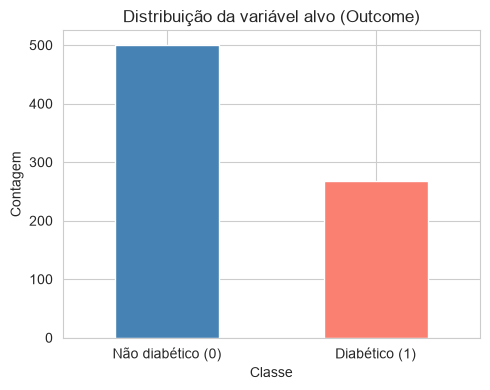

Outcome
0    0.65
1    0.35
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(5, 4))
df['Outcome'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Distribuição da variável alvo (Outcome)')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.xticks([0, 1], ['Não diabético (0)', 'Diabético (1)'], rotation=0)
plt.tight_layout()
plt.show()

print(df['Outcome'].value_counts(normalize=True).round(2))

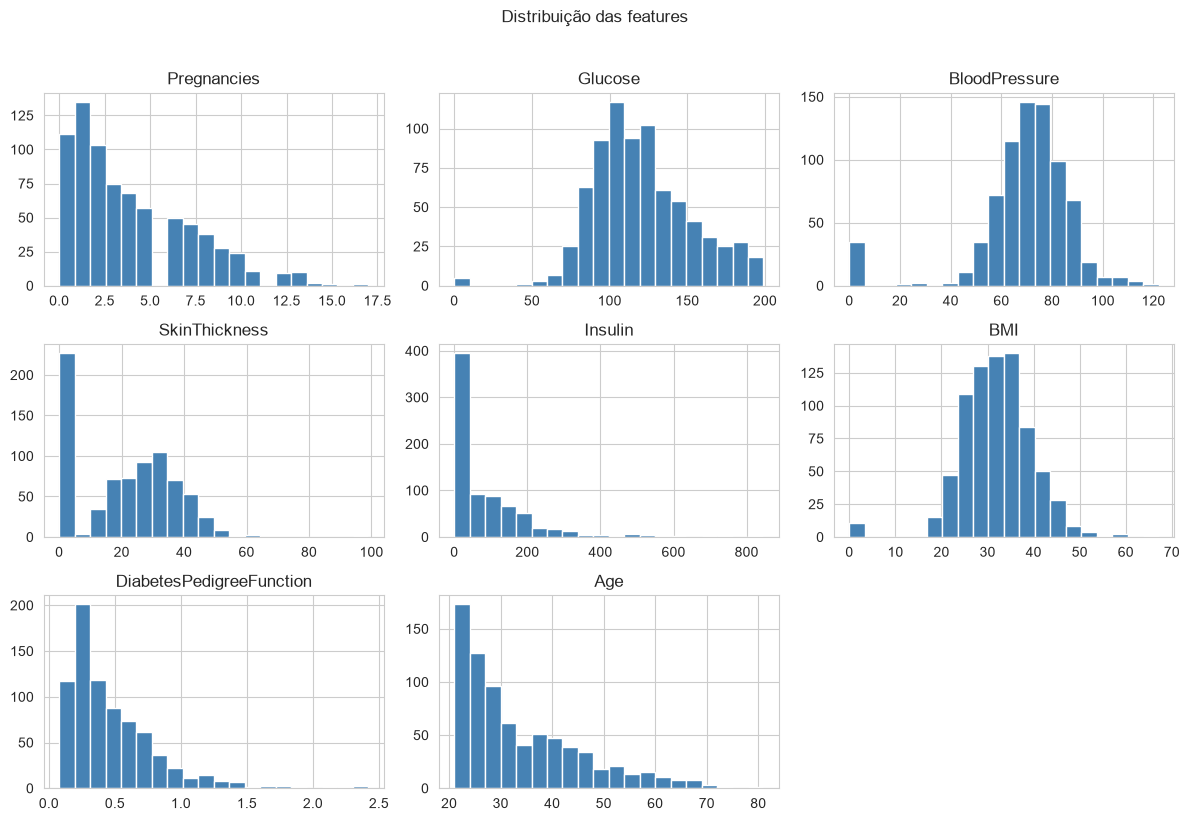

In [7]:
df.drop(columns='Outcome').hist(bins=20, figsize=(12, 8), color='steelblue', edgecolor='white')
plt.suptitle('Distribuição das features', y=1.02)
plt.tight_layout()
plt.show()

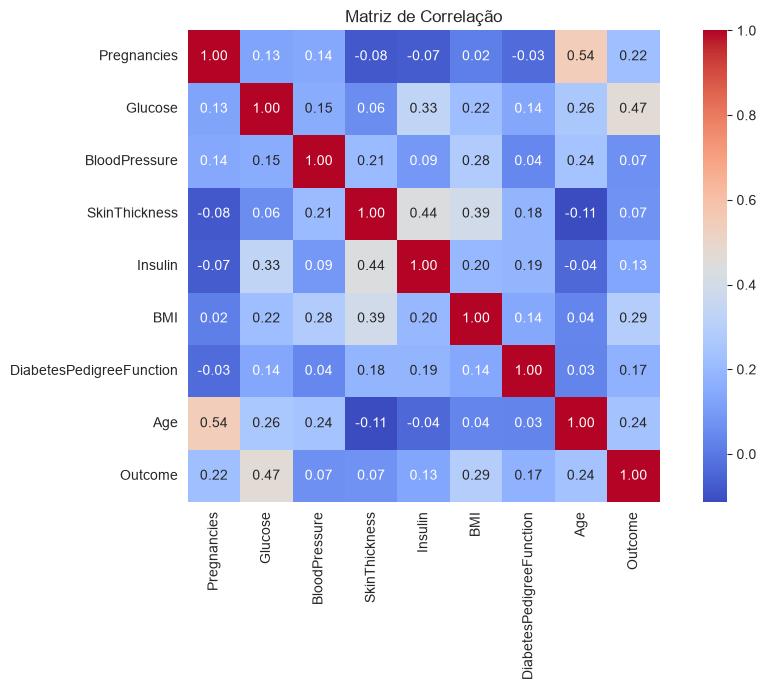

In [8]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

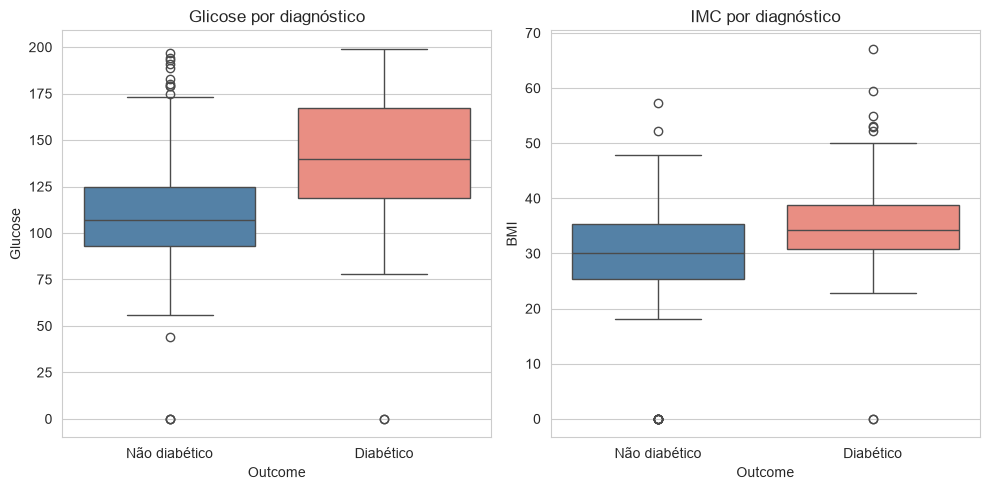

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.boxplot(data=df, x='Outcome', y='Glucose', hue='Outcome',
            palette=['steelblue', 'salmon'], legend=False, ax=axes[0])
axes[0].set_xticklabels(['Não diabético', 'Diabético'])
axes[0].set_title('Glicose por diagnóstico')

sns.boxplot(data=df, x='Outcome', y='BMI', hue='Outcome',
            palette=['steelblue', 'salmon'], legend=False, ax=axes[1])
axes[1].set_xticklabels(['Não diabético', 'Diabético'])
axes[1].set_title('IMC por diagnóstico')

plt.tight_layout()
plt.show()

## 4. Pré-processamento

Etapas:
1. Substituir os zeros inválidos (Glucose, BloodPressure, SkinThickness, Insulin, BMI) pela mediana da coluna.
2. Separar features (`X`) e variável alvo (`y`).
3. Dividir em treino (70%) e teste (30%), mantendo a proporção das classes (`stratify=y`).
4. Normalizar as features com `StandardScaler` — necessário para a Regressão Logística e não prejudica os modelos baseados em árvore, o que permite usar o mesmo pipeline de pré-processamento para os 4 modelos.

In [10]:
for col in colunas_sem_zero:
    mediana = df[col].replace(0, np.nan).median()
    df[col] = df[col].replace(0, mediana)

X = df.drop(columns='Outcome')
y = df['Outcome']
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)
print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_sc = pd.DataFrame(scaler.transform(X_test), columns=feature_names, index=X_test.index)

Treino: 537 amostras | Teste: 231 amostras


## 5. Modelagem

Treinamos 4 modelos de classificação supervisionada e comparamos o desempenho de cada um. Uma função auxiliar padroniza o treino, a predição e o registro das métricas.

In [11]:
resultados = {}
modelos_treinados = {}
probas = {}


def avaliar_modelo(nome, modelo, X_tr, X_te, y_tr, y_te):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]

    resultados[nome] = {
        'Acuracia': accuracy_score(y_te, y_pred),
        'Precisao': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1-Score': f1_score(y_te, y_pred),
        'AUC-ROC': roc_auc_score(y_te, y_proba),
    }
    modelos_treinados[nome] = modelo
    probas[nome] = y_proba

    print(f'--- {nome} ---')
    print(classification_report(y_te, y_pred, target_names=['Nao Diabetico', 'Diabetico']))
    return modelo

### 5.1 Regressão Logística

Modelo linear que estima a probabilidade da classe positiva a partir de uma combinação linear das features. Serve como baseline simples e interpretável.

In [12]:
lr = avaliar_modelo(
    'Regressao Logistica',
    LogisticRegression(max_iter=1000, random_state=SEED),
    X_train_sc, X_test_sc, y_train, y_test,
)

--- Regressao Logistica ---
               precision    recall  f1-score   support

Nao Diabetico       0.77      0.86      0.81       150
    Diabetico       0.67      0.53      0.59        81

     accuracy                           0.74       231
    macro avg       0.72      0.70      0.70       231
 weighted avg       0.74      0.74      0.74       231



### 5.2 Árvore de Decisão

Divide o espaço de features em regiões usando regras de corte (if/else). `max_depth=5` limita a profundidade para reduzir overfitting.

In [13]:
dt = avaliar_modelo(
    'Arvore de Decisao',
    DecisionTreeClassifier(max_depth=5, random_state=SEED),
    X_train_sc, X_test_sc, y_train, y_test,
)

--- Arvore de Decisao ---
               precision    recall  f1-score   support

Nao Diabetico       0.78      0.83      0.80       150
    Diabetico       0.63      0.56      0.59        81

     accuracy                           0.73       231
    macro avg       0.70      0.69      0.70       231
 weighted avg       0.73      0.73      0.73       231



### 5.3 Random Forest

Ensemble de múltiplas árvores treinadas com subconjuntos aleatórios dos dados e das features; a predição final é a votação majoritária.

In [14]:
rf = avaliar_modelo(
    'Random Forest',
    RandomForestClassifier(n_estimators=300, max_depth=6, random_state=SEED),
    X_train_sc, X_test_sc, y_train, y_test,
)

--- Random Forest ---
               precision    recall  f1-score   support

Nao Diabetico       0.77      0.85      0.81       150
    Diabetico       0.66      0.52      0.58        81

     accuracy                           0.74       231
    macro avg       0.71      0.69      0.69       231
 weighted avg       0.73      0.74      0.73       231



### 5.4 XGBoost

Boosting de árvores: cada árvore é treinada para corrigir os erros das anteriores. Um dos algoritmos mais usados em competições de machine learning.

In [15]:
xgb = avaliar_modelo(
    'XGBoost',
    XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.07,
                  eval_metric='logloss', random_state=SEED),
    X_train_sc, X_test_sc, y_train, y_test,
)

--- XGBoost ---
               precision    recall  f1-score   support

Nao Diabetico       0.79      0.83      0.81       150
    Diabetico       0.65      0.58      0.61        81

     accuracy                           0.74       231
    macro avg       0.72      0.71      0.71       231
 weighted avg       0.74      0.74      0.74       231



## 6. Avaliação e Comparação dos Modelos

Resumo das métricas de todos os modelos, gráfico comparativo, matrizes de confusão e curva ROC sobrepondo os 4 modelos.

In [16]:
df_resultados = pd.DataFrame(resultados).T.sort_values('AUC-ROC', ascending=False)
print(df_resultados.round(4))

melhor_nome = df_resultados['AUC-ROC'].idxmax()
melhor_modelo = modelos_treinados[melhor_nome]
print(f'\nMelhor modelo (maior AUC-ROC): {melhor_nome}')

                     Acuracia  Precisao  Recall  F1-Score  AUC-ROC
Regressao Logistica    0.7446    0.6719  0.5309    0.5931   0.8361
Random Forest          0.7359    0.6562  0.5185    0.5793   0.8230
XGBoost                0.7446    0.6528  0.5802    0.6144   0.8172
Arvore de Decisao      0.7316    0.6338  0.5556    0.5921   0.7488

Melhor modelo (maior AUC-ROC): Regressao Logistica


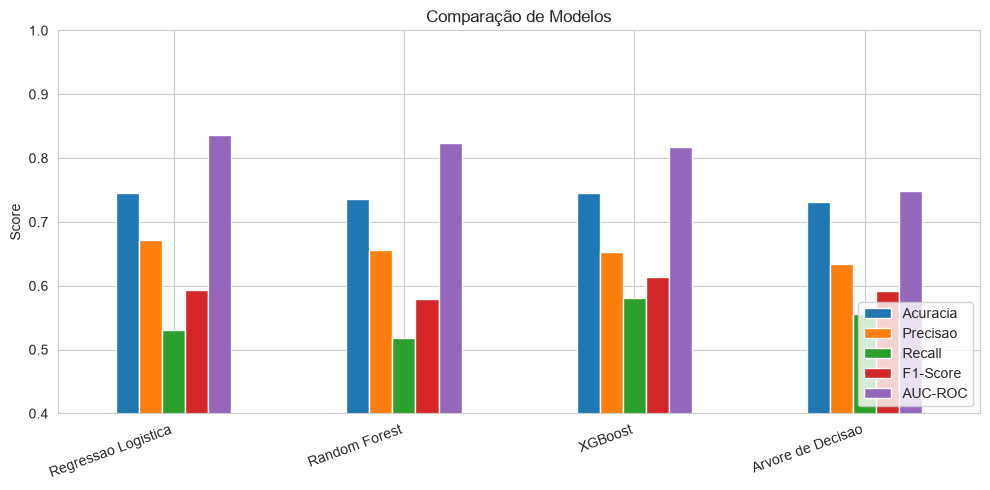

In [17]:
df_resultados[['Acuracia', 'Precisao', 'Recall', 'F1-Score', 'AUC-ROC']].plot(
    kind='bar', figsize=(10, 5)
)
plt.title('Comparação de Modelos')
plt.ylabel('Score')
plt.ylim(0.4, 1.0)
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

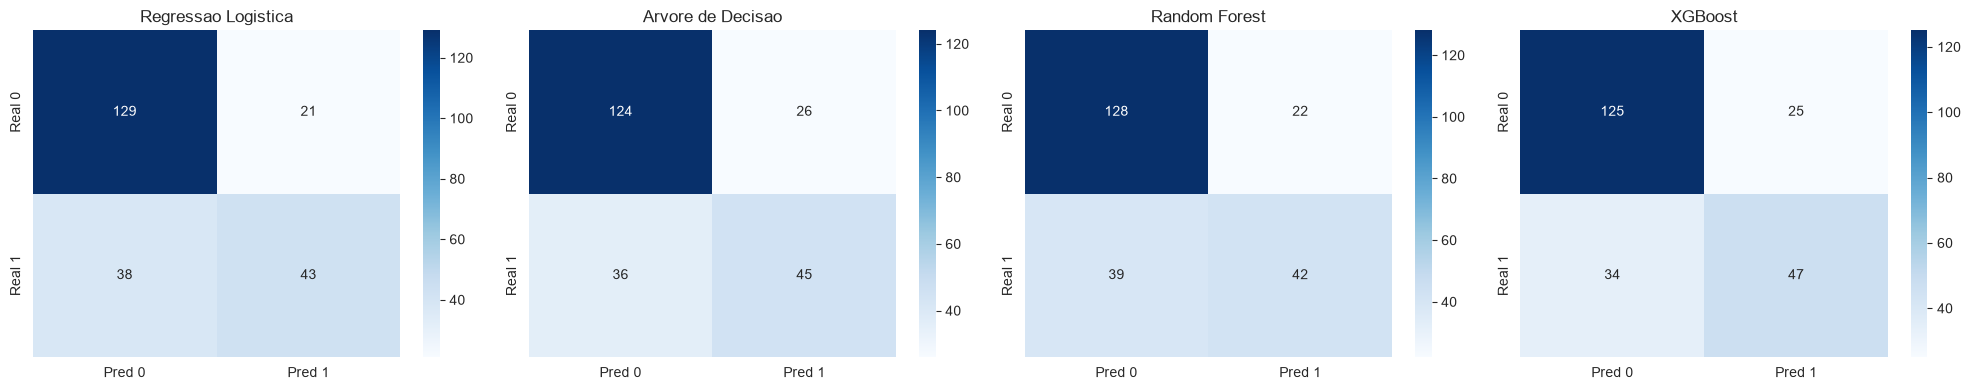

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, nome in zip(axes, resultados.keys()):
    modelo = modelos_treinados[nome]
    y_pred = modelo.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Real 0', 'Real 1'], ax=ax)
    ax.set_title(nome)
plt.tight_layout()
plt.show()

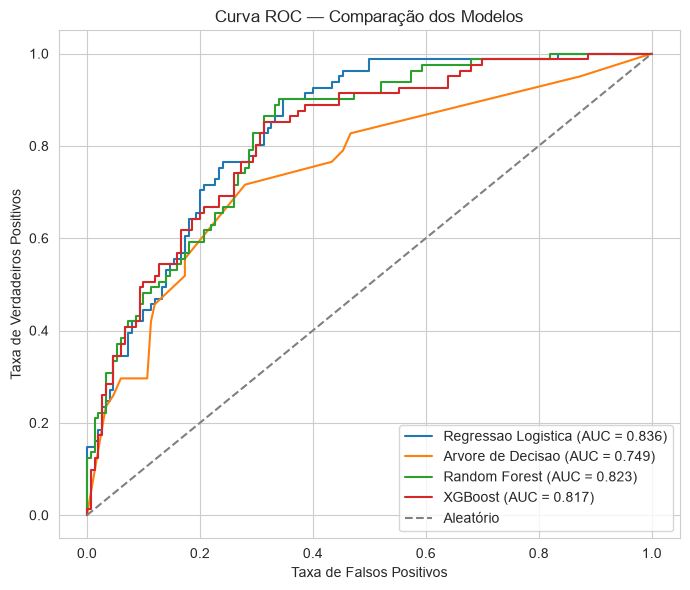

In [19]:
plt.figure(figsize=(7, 6))
for nome, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{nome} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC — Comparação dos Modelos')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Interpretabilidade com SHAP e LIME

Estas seções não fazem parte da estrutura mínima exigida, mas ajudam a explicar *por que* o melhor modelo toma cada decisão — útil para o relatório final.

**SHAP** (`shap.Explainer`, API universal que escolhe automaticamente o algoritmo adequado ao tipo de modelo) mostra a importância global e local de cada feature.

Background dataset has 537 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=537 when initializing the masker.


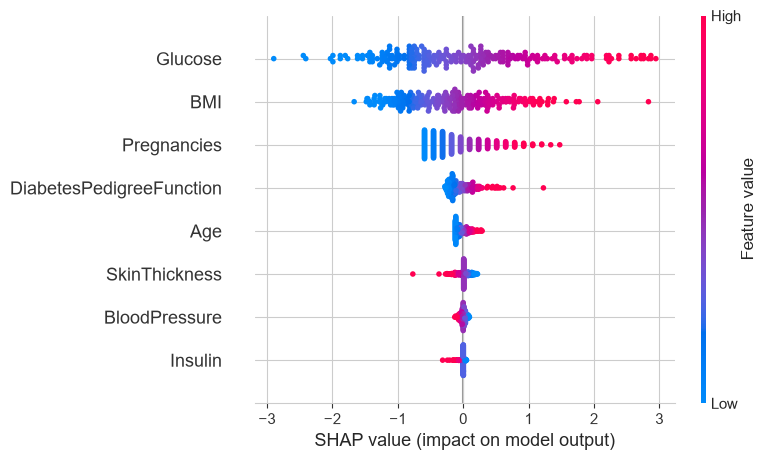

In [20]:
explainer = shap.Explainer(melhor_modelo, X_train_sc)
shap_explanation = explainer(X_test_sc)

# Modelos como Random Forest retornam valores por classe (3 dimensoes);
# nesse caso extraimos a contribuicao para a classe "Diabetico" (indice 1)
if shap_explanation.values.ndim == 3:
    shap_explanation = shap_explanation[:, :, 1]

shap.summary_plot(shap_explanation.values, X_test_sc, show=True)

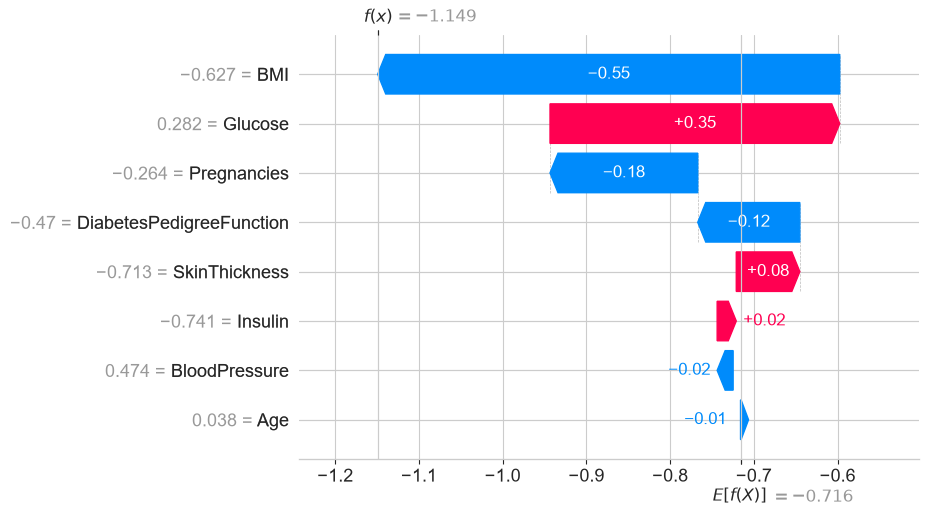

In [21]:
idx = 0
shap.plots.waterfall(shap_explanation[idx], show=True)

**LIME** explica uma predição individual criando um modelo linear simples ao redor da amostra.

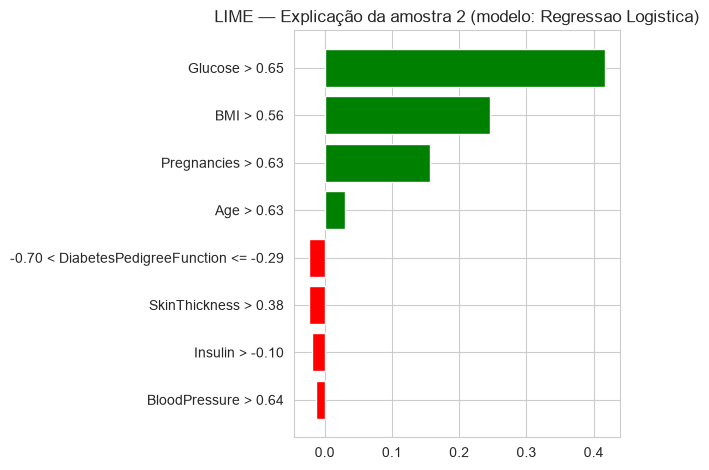

In [22]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_sc.values,
    feature_names=feature_names,
    class_names=['Nao Diabetico', 'Diabetico'],
    mode='classification',
    random_state=SEED,
)

idx_lime = 2
exp = lime_explainer.explain_instance(
    data_row=X_test_sc.iloc[idx_lime].values,
    predict_fn=melhor_modelo.predict_proba,
    num_features=8,
)

exp.as_pyplot_figure()
plt.title(f'LIME — Explicação da amostra {idx_lime} (modelo: {melhor_nome})')
plt.tight_layout()
plt.show()

## 8. Exportação do Melhor Modelo

Salvamos o modelo, o `scaler` e a lista de features com `joblib`, para que a API de predição (próxima etapa do trabalho) use exatamente a mesma normalização e ordem de colunas usadas no treino.

In [23]:
os.makedirs('../modelos', exist_ok=True)

joblib.dump(melhor_modelo, '../modelos/diabetes_melhor_modelo.pkl')
joblib.dump(scaler, '../modelos/diabetes_scaler.pkl')
joblib.dump(feature_names, '../modelos/diabetes_features.pkl')

print(f'Modelo "{melhor_nome}" salvo em ../modelos/diabetes_melhor_modelo.pkl')
print('Scaler salvo em ../modelos/diabetes_scaler.pkl')
print('Lista de features salva em ../modelos/diabetes_features.pkl')

Modelo "Regressao Logistica" salvo em ../modelos/diabetes_melhor_modelo.pkl
Scaler salvo em ../modelos/diabetes_scaler.pkl
Lista de features salva em ../modelos/diabetes_features.pkl


## 9. Predição com Novos Dados

Carregamos o modelo e o scaler salvos e aplicamos o pipeline completo (mesma ordem de colunas + normalização) a 3 pacientes fictícios.

In [24]:
modelo_carregado = joblib.load('../modelos/diabetes_melhor_modelo.pkl')
scaler_carregado = joblib.load('../modelos/diabetes_scaler.pkl')
features_carregadas = joblib.load('../modelos/diabetes_features.pkl')

novos_dados = pd.DataFrame({
    'Pregnancies': [2, 5, 1],
    'Glucose': [120, 180, 90],
    'BloodPressure': [70, 80, 60],
    'SkinThickness': [25, 30, 20],
    'Insulin': [80, 150, 70],
    'BMI': [28.5, 35.0, 22.0],
    'DiabetesPedigreeFunction': [0.35, 0.7, 0.2],
    'Age': [30, 50, 25],
})[features_carregadas]

novos_sc = scaler_carregado.transform(novos_dados)

predicoes = modelo_carregado.predict(novos_sc)
proba_diab = modelo_carregado.predict_proba(novos_sc)[:, 1]

novos_dados['Predicao'] = predicoes
novos_dados['Prob_Diabetes (%)'] = (proba_diab * 100).round(1)
novos_dados['Resultado'] = novos_dados['Predicao'].map({0: 'Nao Diabetico', 1: 'Diabetico'})

print(novos_dados[['Glucose', 'BMI', 'Age', 'Predicao', 'Prob_Diabetes (%)', 'Resultado']].to_string(index=False))

 Glucose  BMI  Age  Predicao  Prob_Diabetes (%)     Resultado
     120 28.5   30         0               15.9 Nao Diabetico
     180 35.0   50         1               88.0     Diabetico
      90 22.0   25         0                2.4 Nao Diabetico


## 10. Conclusão

Este trabalho percorreu o ciclo completo de um projeto de classificação supervisionada sobre o dataset Pima Indians Diabetes (768 registros, 8 features clínicas, variável alvo binária Outcome). Na etapa de pré-processamento, optamos por substituir os zeros clinicamente inválidos (Glucose, BloodPressure, SkinThickness, Insulin, BMI) pela mediana de cada coluna, já que tratá-los como valores reais distorceria a análise — a coluna Insulin, por exemplo, tinha 48.7% de zeros. Também padronizamos todas as features com StandardScaler, o que permitiu usar o mesmo pipeline de inferência para os 4 modelos, incluindo a Regressão Logística, que é sensível à escala das variáveis.

Comparamos quatro algoritmos com naturezas distintas — um modelo linear (Regressão Logística), um modelo baseado em regras (Árvore de Decisão) e dois ensembles de árvores (Random Forest e XGBoost) — usando Acurácia, Precisão, Recall, F1-Score e AUC-ROC como critérios. O AUC-ROC foi o critério de desempate principal por ser mais robusto ao desbalanceamento das classes presente no dataset (~65% não diabético vs. ~35% diabético). Os resultados no conjunto de teste foram:

| Modelo | Acurácia | Precisão | Recall | F1-Score | AUC-ROC |
|---|---|---|---|---|---|
| Regressão Logística | 0.7446 | 0.6719 | 0.5309 | 0.5931 | **0.8361** |
| Random Forest | 0.7359 | 0.6562 | 0.5185 | 0.5793 | 0.8230 |
| XGBoost | 0.7446 | 0.6528 | 0.5802 | 0.6144 | 0.8172 |
| Árvore de Decisão | 0.7316 | 0.6338 | 0.5556 | 0.5921 | 0.7488 |

A **Regressão Logística** foi o melhor modelo pelo critério AUC-ROC (0.8361), superando até os ensembles mais complexos — um resultado que reforça que, neste dataset relativamente pequeno e com relações majoritariamente lineares entre glicose/IMC/idade e o risco de diabetes, um modelo simples e interpretável generaliza tão bem ou melhor que modelos mais sofisticados, além de ser o mais barato de manter e explicar. O XGBoost obteve o melhor Recall (0.5802), o que pode ser relevante caso o objetivo de negócio priorize minimizar falsos negativos (não deixar de identificar pacientes diabéticos).

As seções de interpretabilidade com SHAP e LIME confirmaram que Glucose, BMI, Age e DiabetesPedigreeFunction estão entre as features mais influentes nas predições, o que é coerente com o conhecimento clínico sobre fatores de risco para diabetes tipo 2.

Como limitações, destacamos: o dataset é pequeno (768 amostras) e desbalanceado, o que limita a generalização do modelo e penaliza o Recall de todos os modelos testados; a imputação por mediana é uma simplificação — técnicas mais sofisticadas (KNNImputer, MICE) poderiam captar melhor as relações entre as variáveis; e nenhuma otimização extensiva de hiperparâmetros (GridSearch/Optuna) foi realizada, o que deixa espaço para ganhos adicionais de desempenho, especialmente em Recall. Como trabalho futuro, o modelo, o scaler e a lista de features exportados aqui (pasta `backend/modelos/`) serão consumidos por uma API FastAPI e por uma interface web em React, completando o ciclo de disponibilização do modelo ao usuário final.